# Dataset Sample - Rate

This notebook answers a specific preprocessing question: should this dataset be resampled to `16 kHz`, `22.05 kHz`, or something else?

It inspects the dataset's native sampling rates, durations and channel counts before making a recommendation. It does not train a model, extract MFCCs, or change any cache.


## 1. Package Setup


In [1]:
# Purpose: Package installs are shown for fresh environments but are not run automatically.
# %pip install soundfile pandas numpy matplotlib seaborn


## 2. Imports, Configuration and Paths


In [2]:
# Purpose: Configure the dataset locations and output folder for this standalone audit.
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf

try:
    from IPython.display import display
except Exception:
    display = print

AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}

# Purpose: This is the rate currently used by the project MFCC notebooks. The audit checks
# whether this is defensible from the files, rather than assuming 16 kHz because ASVspoof
# speech benchmarks commonly use it.
CURRENT_PROJECT_SAMPLE_RATE = 22050
COMMON_SPEECH_BENCHMARK_SAMPLE_RATE = 16000





In [3]:
# Purpose: Defines and calls a portable helper that mounts Google Drive when Colab is available
# and otherwise continues without failing in a local environment.
# Mount Google Drive when the notebook is running in Colab.
def mount_drive_if_colab(mount_point="/content/drive"):
    try:
        from google.colab import drive
        drive.mount(mount_point)
    except Exception:
        print("Not running in Colab, or Google Drive is already available.")

mount_drive_if_colab()


Mounted at /content/drive


In [4]:
def resolve_project_root():
    # Purpose: default path.
    explicit = os.environ.get("INTRO_AI_PROJECT_ROOT")
    if explicit:
        return Path(explicit).expanduser().resolve()
    cwd = Path.cwd().resolve()
    # Purpose: Runs each candidate configuration under the same data split for a fair validation comparison.
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Model Variants").exists():
            return candidate
        if (candidate / "Training" / "Model Variants").exists():
            return candidate / "Training"
    return Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")


def first_existing_path(candidates):
    # Purpose: none exist.
    expanded = []
    # Purpose: Runs each candidate configuration under the same data split for a fair validation comparison.
    for candidate in candidates:
        if candidate in [None, ""]:
            continue
        expanded.append(Path(candidate).expanduser())
    # Purpose: Iterates over this collection to build the next table, feature set, or experiment result
    # Purpose: consistently.
    for path in expanded:
        if path.exists():
            return path
    return expanded[0]


# Purpose: Centralizes filesystem paths so dataset inputs, caches, figures, models, and metric tables are easy
# Purpose: to trace.
PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / "Data"
SYNTHETIC_AUDIO_DIR = first_existing_path([
    os.environ.get("MLAAD_SYNTHETIC_AUDIO_DIR", ""),
    DATA_ROOT / "MLAAD_10pct" / "fake",
    DATA_ROOT / "Unprocessed" / "MLAAD_10pct" / "fake",
    DATA_ROOT / "MLAAD_10pct",
    PROJECT_ROOT / "MLAAD_10pct" / "fake",
    PROJECT_ROOT / "MLAAD_10pct",
])
BONA_FIDE_AUDIO_DIR = first_existing_path([
    os.environ.get("MLAAD_BONA_FIDE_AUDIO_DIR", ""),
    DATA_ROOT / "genuine_audio",
    DATA_ROOT / "bona_fide",
    DATA_ROOT / "Unprocessed" / "genuine_audio",
    PROJECT_ROOT / "genuine_audio",
    PROJECT_ROOT / "bona_fide",
])

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "shared" / "sample_rate_audit"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
# Purpose: Creates each output directory before later cells try to save tables, figures, or models.
for directory in [OUTPUT_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Synthetic audio directory:", SYNTHETIC_AUDIO_DIR)
print("Bona-fide audio directory:", BONA_FIDE_AUDIO_DIR)

Project root: /content/drive/MyDrive/Colab Notebooks/Education/INM701
Synthetic audio directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Data/MLAAD_10pct/fake
Bona-fide audio directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Data/genuine_audio


## 3. Scan Audio File Paths


In [5]:
# Purpose: Find audio files and keep class/language/generator metadata visible enough for
# class-wise sampling-rate checks.
def parse_synthetic_metadata(path, root_dir):
    # Purpose: Extracts synthetic-language and generator labels from the dataset folder structure.
    parts = path.relative_to(root_dir).parts
    if parts and parts[0].lower() == "fake" and len(parts) >= 3:
        return parts[1], parts[2]
    if len(parts) >= 2:
        return parts[0], parts[1]
    return "unknown", "unknown"


def parse_bona_fide_metadata(path, root_dir):
    # Purpose: Extracts bona-fide metadata from the dataset folder structure when it is available.
    parts = path.relative_to(root_dir).parts
    language = parts[0] if len(parts) >= 2 else "unknown"
    return language, "bona_fide"


def scan_audio_paths(root_dir, label, class_name, source_kind):
    # Purpose: Keeps the scan_audio_paths helper isolated so later notebook cells can call it consistently.
    root_dir = Path(root_dir)
    rows = []
    if not root_dir.exists():
        print("Directory missing:", root_dir)
        return pd.DataFrame(rows)
    # Purpose: Iterates over this collection to build the next table, feature set, or experiment result
    # Purpose: consistently.
    for path in sorted(root_dir.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in AUDIO_EXTENSIONS:
            continue
        if source_kind == "synthetic":
            language, tts_generator = parse_synthetic_metadata(path, root_dir)
        else:
            language, tts_generator = parse_bona_fide_metadata(path, root_dir)
        rows.append({
            "path": str(path.resolve()),
            "relative_path": str(path.relative_to(root_dir)),
            "label": int(label),
            "class_name": class_name,
            "language": language,
            "tts_generator": tts_generator,
            "file_size_mb": path.stat().st_size / (1024 * 1024),
        })
    return pd.DataFrame(rows)


synthetic_files = scan_audio_paths(SYNTHETIC_AUDIO_DIR, 1, CLASS_NAMES[1], "synthetic")
bona_fide_files = scan_audio_paths(BONA_FIDE_AUDIO_DIR, 0, CLASS_NAMES[0], "bona_fide")
file_manifest = pd.concat([bona_fide_files, synthetic_files], ignore_index=True)

if file_manifest.empty:
    raise RuntimeError("No audio files were found. Check dataset paths before auditing sampling rates.")

print("Audio files found:", len(file_manifest))
display(file_manifest.groupby("class_name").size().reset_index(name="files"))


Audio files found: 11196


,class_name,files
0,bona_fide,3997
1,synthetic,7199


## 4. Read Native Audio Metadata


In [6]:
# Purpose: Read physical file metadata without loading full waveforms. This is much cheaper
# than extracting MFCCs and is enough for choosing a target sampling rate.
def read_audio_metadata(path):
    # Purpose: Keeps the read_audio_metadata helper isolated so later notebook cells can call it consistently.
    try:
        info = sf.info(path)
        return {
            "path": str(path),
            "audio_info_ok": True,
            "native_sample_rate": int(info.samplerate),
            "channels": int(info.channels),
            "frames": int(info.frames),
            "duration_seconds": float(info.frames) / float(info.samplerate) if info.samplerate else np.nan,
            "audio_info_error": "",
        }
    except Exception as exc:
        return {
            "path": str(path),
            "audio_info_ok": False,
            "native_sample_rate": np.nan,
            "channels": np.nan,
            "frames": np.nan,
            "duration_seconds": np.nan,
            "audio_info_error": str(exc),
        }


audio_metadata = pd.DataFrame([read_audio_metadata(path) for path in file_manifest["path"]])
audit_df = file_manifest.merge(audio_metadata, on="path", how="left", validate="one_to_one")
# Purpose: Saves the generated artifacts so later notebooks, reports, or reruns can inspect the same outputs.
audit_df.to_csv(TABLES_DIR / "dataset_sample_rate_audit.csv", index=False)

print("Metadata rows:", len(audit_df))
print("Unreadable files:", int((~audit_df["audio_info_ok"]).sum()))
display(audit_df.head())


Metadata rows: 11196
Unreadable files: 0


,path,relative_path,label,class_name,language,tts_generator,file_size_mb,audio_info_ok,native_sample_rate,channels,frames,duration_seconds,audio_info_error
0,/content/drive/MyDrive/Colab Notebooks/Educati...,genuine_audio/en/de/Die_Kanzlerin_direkt_16_07...,0,bona_fide,genuine_audio,bona_fide,0.218805,True,16000,1,114678,7.167375,
1,/content/drive/MyDrive/Colab Notebooks/Educati...,genuine_audio/en/de/Die_Kanzlerin_direkt_20_08...,0,bona_fide,genuine_audio,bona_fide,0.118643,True,16000,1,62164,3.885250,
2,/content/drive/MyDrive/Colab Notebooks/Educati...,genuine_audio/en/de/Die_Kanzlerin_direkt_21_08...,0,bona_fide,genuine_audio,bona_fide,0.206894,True,16000,1,108433,6.777063,
3,/content/drive/MyDrive/Colab Notebooks/Educati...,genuine_audio/en/de/Die_Kanzlerin_direkt_25_07...,0,bona_fide,genuine_audio,bona_fide,0.306057,True,16000,1,160423,10.026438,
4,/content/drive/MyDrive/Colab Notebooks/Educati...,genuine_audio/en/de/Die_Kanzlerin_direkt_44_12...,0,bona_fide,genuine_audio,bona_fide,0.073606,True,16000,1,38552,2.409500,


## 5. Summarise Native Sample Rates


In [7]:
# Purpose: Summarise which sampling rates actually occur in the dataset before deciding a
# preprocessing target.
sample_rate_counts = (
    audit_df.dropna(subset=["native_sample_rate"])
    .groupby("native_sample_rate")
    .size()
    .reset_index(name="files")
    .sort_values("files", ascending=False)
)
sample_rate_counts["share"] = sample_rate_counts["files"] / sample_rate_counts["files"].sum()

sample_rate_by_class = (
    audit_df.dropna(subset=["native_sample_rate"])
    .groupby(["class_name", "native_sample_rate"])
    .size()
    .reset_index(name="files")
    .sort_values(["class_name", "files"], ascending=[True, False])
)
channel_counts = audit_df["channels"].value_counts(dropna=False).rename_axis("channels").reset_index(name="files")
duration_summary = audit_df.groupby("class_name")["duration_seconds"].describe().reset_index()

# Purpose: Saves the generated artifacts so later notebooks, reports, or reruns can inspect the same outputs.
sample_rate_counts.to_csv(TABLES_DIR / "sample_rate_counts.csv", index=False)
sample_rate_by_class.to_csv(TABLES_DIR / "sample_rate_by_class.csv", index=False)
channel_counts.to_csv(TABLES_DIR / "channel_counts.csv", index=False)
duration_summary.to_csv(TABLES_DIR / "duration_summary.csv", index=False)

display(sample_rate_counts)
display(sample_rate_by_class)
display(channel_counts)
display(duration_summary)


,native_sample_rate,files,share
1,22050,7199,0.642997
0,16000,3997,0.357003


,class_name,native_sample_rate,files
0,bona_fide,16000,3997
1,synthetic,22050,7199


,channels,files
0,1,11196


,class_name,count,mean,std,min,25%,50%,75%,max
0,bona_fide,3997.0,7.356297,2.941417,0.732938,5.079875,7.179875,9.519875,23.583437
1,synthetic,7199.0,7.220658,3.906641,0.371519,4.480000,6.720000,9.241542,43.733333


## 6. Plot Sample-Rate and Duration Distributions


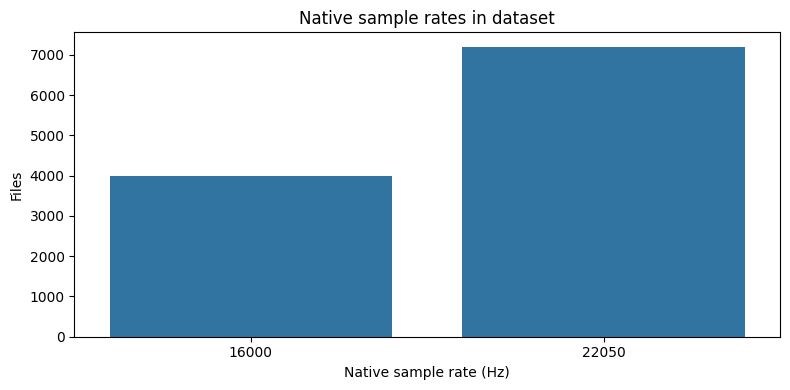

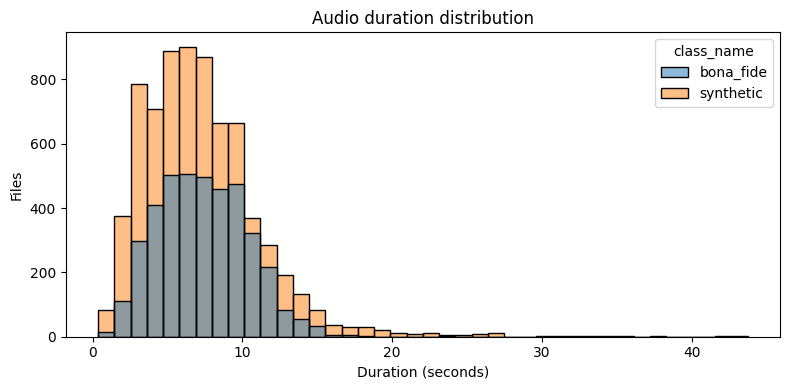

In [8]:
# Purpose: Save simple figures that can be referenced in the report.
plt.figure(figsize=(8, 4))
sns.barplot(data=sample_rate_counts, x="native_sample_rate", y="files")
plt.title("Native sample rates in dataset")
plt.xlabel("Native sample rate (Hz)")
plt.ylabel("Files")
plt.tight_layout()
# Purpose: Saves the generated artifacts so later notebooks, reports, or reruns can inspect the same outputs.
plt.savefig(FIGURES_DIR / "native_sample_rate_counts.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=audit_df, x="duration_seconds", hue="class_name", bins=40)
plt.title("Audio duration distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Files")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "duration_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Recommendation Logic


In [9]:
# Purpose: Convert the audit into a transparent recommendation. This is not a universal
# DSP law; it is a dataset-specific decision rule.
if sample_rate_counts.empty:
    raise RuntimeError("No readable sample rates were found.")

dominant_rate = int(sample_rate_counts.iloc[0]["native_sample_rate"])
dominant_share = float(sample_rate_counts.iloc[0]["share"])
unique_rates = sample_rate_counts["native_sample_rate"].astype(int).tolist()
has_rates_above_16k = any(rate > COMMON_SPEECH_BENCHMARK_SAMPLE_RATE for rate in unique_rates)

if dominant_share >= 0.80:
    recommended_rate = dominant_rate
    reason = "Most files already share this native rate, so using it avoids unnecessary resampling."
elif CURRENT_PROJECT_SAMPLE_RATE in unique_rates:
    recommended_rate = CURRENT_PROJECT_SAMPLE_RATE
    reason = "The project rate appears in the dataset and preserves more bandwidth than 16 kHz."
elif has_rates_above_16k:
    recommended_rate = CURRENT_PROJECT_SAMPLE_RATE
    reason = "The dataset contains rates above 16 kHz; 22.05 kHz is a conservative project-level standard unless experiments justify 16 kHz."
else:
    recommended_rate = COMMON_SPEECH_BENCHMARK_SAMPLE_RATE
    reason = "The dataset does not show useful evidence for a higher target rate, and 16 kHz is common for speech anti-spoofing."

recommendation = {
    "dominant_native_sample_rate": dominant_rate,
    "dominant_native_sample_rate_share": dominant_share,
    "all_native_sample_rates": unique_rates,
    "current_project_sample_rate": CURRENT_PROJECT_SAMPLE_RATE,
    "common_speech_benchmark_sample_rate": COMMON_SPEECH_BENCHMARK_SAMPLE_RATE,
    "recommended_target_sample_rate": int(recommended_rate),
    "reason": reason,
    "important_note": "If this is singing/music rather than speech-only, avoid assuming 16 kHz without validation because higher-frequency content may matter.",
}

with open(TABLES_DIR / "sample_rate_recommendation.json", "w", encoding="utf-8") as f:
    json.dump(recommendation, f, indent=2)

display(pd.DataFrame(list(recommendation.items()), columns=["item", "value"]))


,item,value
0,dominant_native_sample_rate,22050
1,dominant_native_sample_rate_share,0.642997
2,all_native_sample_rates,"[22050, 16000]"
3,current_project_sample_rate,22050
4,common_speech_benchmark_sample_rate,16000
5,recommended_target_sample_rate,22050
6,reason,The project rate appears in the dataset and pr...
7,important_note,If this is singing/music rather than speech-on...


## 8. Report Wording Template


In [10]:
# Purpose: Generate cautious wording for the report after the audit has been run.
wording = f'''
The dataset was audited for native sampling rates before choosing the preprocessing target.
The most common native sample rate was {dominant_rate} Hz, covering {dominant_share:.1%} of readable files.
Based on this audit, the recommended target sample rate is {recommended_rate} Hz.
This target rate should be applied consistently to train, validation and test audio before MFCC extraction.
The choice is dataset-specific and should not be justified only by the fact that some speech benchmarks use 16 kHz.
'''
print(wording)



The dataset was audited for native sampling rates before choosing the preprocessing target.
The most common native sample rate was 22050 Hz, covering 64.3% of readable files.
Based on this audit, the recommended target sample rate is 22050 Hz.
This target rate should be applied consistently to train, validation and test audio before MFCC extraction.
The choice is dataset-specific and should not be justified only by the fact that some speech benchmarks use 16 kHz.



## 9. Checks


In [11]:
# Purpose: Defines audio preprocessing and feature-extraction helpers used before model training.
checks = {
    "uses_native_file_metadata_not_waveform_features": True,
    "does_not_train_model": True,
    "does_not_extract_mfcc": True,
    "does_not_change_existing_caches": True,
    "outputs_table": str(TABLES_DIR / "dataset_sample_rate_audit.csv"),
    "outputs_recommendation": str(TABLES_DIR / "sample_rate_recommendation.json"),
}
display(pd.DataFrame(list(checks.items()), columns=["check", "value"]))


,check,value
0,uses_native_file_metadata_not_waveform_features,True
1,does_not_train_model,True
2,does_not_extract_mfcc,True
3,does_not_change_existing_caches,True
4,outputs_table,/content/drive/MyDrive/Colab Notebooks/Educati...
5,outputs_recommendation,/content/drive/MyDrive/Colab Notebooks/Educati...
